# Free Energy - CV

In [1]:
import torch
import torchvision.models as models
import numpy as np
import os
import matplotlib.pyplot as plt

## Save eigenvalues to dict for matrix

In [2]:
def get_fc(model):
    if isinstance(model, models.vision_transformer.VisionTransformer):
        return model.heads[-1].weight.detach().cpu().flatten(1, -1)
    elif isinstance(model, models.swin_transformer.SwinTransformer):
        return model.head.weight.detach().cpu().flatten(1, -1)
    elif hasattr(model, 'fc'):
        return model.fc.weight.detach().cpu().flatten(1, -1)
    elif hasattr(model, 'classifier'):
        # if isinstance(model, models.vgg.VGG):
        #     return model.classifier[0].weight.detach().cpu().flatten(1, -1).T
        if hasattr(model.classifier, 'weight'):
            return model.classifier.weight.detach().cpu().flatten(1, -1)
        elif len(model.classifier) > 0 and hasattr(model.classifier[-1], 'weight'):
            return model.classifier[-1].weight.detach().cpu().flatten(1, -1)
        # Else take the final conv layer
        else:
            for p in model.classifier:
                if hasattr(p, 'weight'):
                    return p.weight.detach().cpu().flatten(1, -1)
        
    raise ValueError("Model does not have a recognized fully connected layer.")

In [3]:
def get_deep_conv(model):
    # for name, param in reversed(list(model.named_parameters())):
    #     if 'conv' in name or 'Conv' in type(model).__name__:
    #         W = param.detach().cpu().flatten(1, -1)
    #         return W
    for name, param in list(model.named_parameters()):
        if param.requires_grad and len(param.shape) == 4:
            W = param.detach().cpu().flatten(1, -1)
            print(name)
            return W
    print("No convolutional layer found, returning None.")
    return None
   

In [4]:
def save_eigenvalues_metrics(model_name, data_root = None, save_path = 'data/htmp/models', weight_type='final'):
    if data_root is not None:
        torch.hub.set_dir(data_root)
    os.makedirs(save_path, exist_ok=True)
    weight_enum = torch.hub.load("pytorch/vision", "get_model_weights", name=model_name)
    weights = weight_enum.DEFAULT
    metrics = weights.meta['_metrics']['ImageNet-1K']
    model = models.get_model(name=model_name, weights='DEFAULT').eval()
    if weight_type == 'final':
        W = get_fc(model)
        weight_name = ''
    elif weight_type == 'deep_conv':
        weight_name = '_deep_conv'
        if isinstance(model, models.vision_transformer.VisionTransformer):
            print(f"Model {model_name} is a transformer.")
            W = model.encoder.layers[-1].self_attention.out_proj.weight
        else:
            W = get_deep_conv(model)
            if W is None:
                print(f"No convolutional layer found for model {model_name}, skipping.")
                return
    if W.shape[0] > W.shape[1]:
        W = W.t()
    print(W.shape)
    e = torch.linalg.eigvalsh(W @ W.t())
    res_dict = {
        'model_name': model_name,
        'acc5': metrics['acc@5'],
        'acc1': metrics['acc@1'],
        'eigenvalues': e,
        'gamma': W.shape[0] / W.shape[1],
    }
    torch.save(res_dict, f'{save_path}/{model_name}{weight_name}_eigs.pt')

In [5]:
vgg_models = models.list_models(include='vgg*') # Dropout --> Terrible
mnasnet_models = models.list_models(include='mnasnet*') # Dropout, ---> Terrible
efficientnet_models = models.list_models(include='efficientnet*') # Dropout --> Terrible
mobilenet_models = models.list_models(include='mobilenet*') # Dropout ---> Good, wrong scale

swin_models = models.list_models(include='swin*')[3:] # transformer - bad
vit_models = models.list_models(include='vit*') # transformer - bad

alexnet_models = models.list_models(include='alexnet*') # Old --> Terrible
googlenet_models = models.list_models(include='googlenet*') # Old --> Terrible

resnet_models = models.list_models(include='resnet*') # No Dropout ---> Good
resnext_models = models.list_models(include='resnext*') # No Dropout ---> Good
convnext_models = models.list_models(include='convnext*') # No Dropout ---> Good
wide_resnet_models = models.list_models(include='wide_resnet*') # No Dropout ---> Good
regnet_models = models.list_models(include='regnet*') # No Dropout ---> Good
densenet_models = models.list_models(include='dense*') # No Dropout ---> Good
inception_models = models.list_models(include='inception*') # No Dropout ---> Good
shufflenet_models = models.list_models(include='shufflenet*') # No Dropout ---> Good

squeezenet_models = models.list_models(include='squeezenet*') # No Dropout ---> Good, wrong scale, maybe due to 'squeeze' architecture?


resnet_type_models = resnet_models + resnext_models + wide_resnet_models + regnet_models + convnext_models + densenet_models + inception_models + shufflenet_models
dropout_models = vgg_models + mnasnet_models + efficientnet_models + mobilenet_models
transformer_models = vit_models + swin_models
old_models = alexnet_models + googlenet_models

weird_models = squeezenet_models

vgg_models_bn = [model for model in vgg_models if 'bn' in model]
vgg_models_no_bn = [model for model in vgg_models if 'bn' not in model]

In [ ]:
for model_name in resnet_type_models:
    print(f'Saving eigenvalues and metrics for {model_name}...')
    save_eigenvalues_metrics(model_name, save_path='results/cv', weight_type='final')

## Plot BFE-W vs. Test Acc

In [6]:
def sort_architectures(model_names):
    arch_types = []
    for name in model_names:
        if 'resnet' in name:
            arch_types.append('ResNet')
        elif 'dense' in name.lower():
            arch_types.append('DenseNet')
        elif 'vit' in name.lower():
            arch_types.append('ViT*')
        elif 'swin' in name.lower():
            arch_types.append('Swin*')
        elif 'convnext' in name.lower():
            arch_types.append('ConvNeXt')
        elif 'regnet' in name.lower():
            arch_types.append('RegNet')
        elif 'efficientnet' in name.lower():
            arch_types.append('EfficientNet')
        elif 'resnext' in name.lower():
            arch_types.append('ResNeXt')
        elif 'inception' in name.lower():
            arch_types.append('Inception')
        elif 'shufflenet' in name.lower():
            arch_types.append('ShuffleNet')
        elif 'squeezenet' in name.lower():
            arch_types.append('SqueezeNet')
        elif 'mobilenet' in name.lower():
            arch_types.append('MobileNet')
        elif 'mnasnet' in name.lower():
            arch_types.append('MNASNet')
        elif 'vgg' in name.lower():
            arch_types.append('VGG')
        else:
            arch_types.append('Other')

    return arch_types

In [8]:
def mean_bfe(e, lam=1, n = 1000, jitter=1e-2):
    fro_norm = torch.sum(e + jitter).item() / n
    logdet_term = torch.sum(torch.log((e + jitter))).item() / n
    free_energy = lam/2 * fro_norm - 0.5 * logdet_term + 1/2 * np.log(2 * np.pi / lam)
    return free_energy

In [7]:
def mean_bfe_unnormalized(e, lam=1, n = 1000, jitter=1e-2):
    fro_norm = torch.sum(e + jitter).item() / n
    logdet_term = torch.sum(torch.log((e + jitter)/lam)).item() / n
    free_energy = lam/2 * fro_norm - 0.5 * logdet_term
    return free_energy

In [9]:
def optim_lam(e, lam_min=1e-3, lam_max=1e3, num_lams=100, jitter=1e-2, n=1000):
    lams = np.logspace(np.log10(lam_min), np.log10(lam_max), num_lams)
    free_energies = [mean_bfe(e, lam, n, jitter=jitter) for lam in lams]
    optimal_lam = lams[np.argmin(free_energies)]
    optimal_free_energy = min(free_energies)
    return optimal_lam, optimal_free_energy

In [10]:
import powerlaw
from scipy import stats
import weightwatcher.WW_powerlaw as WW_powerlaw
import weightwatcher.weightwatcher as ww_core

def compute_correlation(x, y, method='pearson'):
    method = method.lower()
    if method == 'pearson':
        return np.corrcoef(x, y)[0, 1]
    if method == 'spearman':
        return stats.spearmanr(x, y).statistic
    if method == 'kendall':
        res = stats.kendalltau(x, y)
        return res.statistic, res.pvalue
    raise ValueError("method must be one of: 'pearson', 'spearman', 'kendall'")

def patched_pl_fit(
    data=None,
    xmin=None,
    xmax=None,
    verbose=False,
    distribution=None,
    pl_package=None,
    **kwargs,
 ):
    return powerlaw.Fit(
        data,
        xmin=xmin,
        xmax=xmax,
        discrete=False,
        verbose=verbose,
    )

# patch both references
WW_powerlaw.pl_fit = patched_pl_fit
ww_core.pl_fit = patched_pl_fit

PyTorch is available but CUDA is not. Defaulting to SciPy for SVD
Import error , reetting to svd accurate methods


  0%|          | 0/38 [00:00<?, ?it/s]

100%|██████████| 38/38 [00:00<00:00, 59.86it/s]


overall
Overall Pearson correlation: -0.8575
Overall Spearman correlation: -0.7278
Overall Kendall correlation: -0.5733, p-value: 4.0524e-07


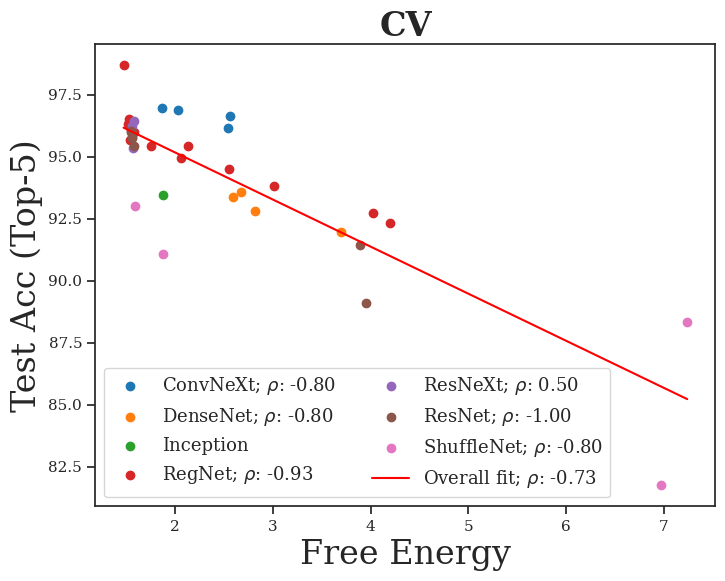

                 model   acc@5   acc@1  Free Energy       min_eig  \
26      convnext_large  96.976  84.414     1.861650  2.423146e-02   
28       convnext_tiny  96.146  82.520     2.542766 -1.953463e-06   
25       convnext_base  96.870  84.062     2.030052  1.205877e-04   
27      convnext_small  96.650  83.616     2.558847 -1.676655e-06   
32         densenet201  93.370  76.896     2.590974 -2.970740e-07   
31         densenet169  92.806  75.600     2.816950 -1.763148e-06   
30         densenet161  93.560  77.138     2.672617 -1.733160e-06   
29         densenet121  91.972  74.434     3.697615 -2.797710e-06   
33        inception_v3  93.450  77.294     1.871621  1.863651e-03   
24        regnet_y_8gf  96.330  82.828     1.551769 -5.841255e-06   
23      regnet_y_800mf  94.502  78.828     2.550436 -2.463813e-06   
22      regnet_y_400mf  92.742  75.804     4.024079 -2.813723e-06   
21      regnet_y_3_2gf  95.972  81.982     1.575687 -6.426126e-08   
20       regnet_y_32gf  96.498  83

In [11]:
from importlib import reload; import texplot; texplot.set_theme(); import json; import tqdm

fig_height = 6; fig_width = 8; font_size = 24; legend_size = 13; plot_ww = False; weight_watchers_all_weights = True
accs1 = []
accs5 = []

LOG_FROB_NORM = 'lognorm'
LOG_SPECTRAL_NORM = 'logspectralnorm'
ALPHA_WEIGHTED = 'alpha_weighted'
ALPHA_NORM = 'logpnorm'
DIR = 'old_ww_current_torchvision_all_default_spectralnorms'
corr_method = 'spearman'  # 'pearson', 'spearman', or 'kendall'

# Metrics
metrics = {
    'Free Energy': [],
    'Log Frobenius Norm': [],
    'Log Infinity Norm': [],
    'Weighted-α': [],
    'α-Norm': [],
}

model_category = 'ResNetType'  # 'ResNetType', 'Dropout', 'Transformer', 'Old'
if model_category == 'ResNetType':
    combined_models = resnet_type_models
elif model_category == 'Dropout':
    combined_models = dropout_models
elif model_category == 'Transformer':
    combined_models = transformer_models
elif model_category == 'Old':
    combined_models = old_models

f = '_eigs.pt'
lfn = 0; linf = 0; weight_alpha = 0; alpha_norm = 0

min_eigs = []
aspect_ratios = []
for model_name in tqdm.tqdm(combined_models):
    res_dict = torch.load(f'results/cv/{model_name}{f}')
    e = res_dict['eigenvalues']
    try:
        aspect_ratios.append(res_dict['gamma'])
    except:
        aspect_ratios.append(len(e))
    min_eigs.append(e.min().item())
    accs5.append(res_dict['acc5'])
    accs1.append(res_dict['acc1'])
    opt_lam, opt_free_energy = optim_lam(e, jitter=1e-4, n=1000, num_lams=1000)
    metrics['Free Energy'].append(opt_free_energy)
    
    if plot_ww:
        WW_res = json.load(open(f'{DIR}/summaries/{model_name}_summary.json', 'r'))
        lfn = WW_res[LOG_FROB_NORM]
        linf = WW_res[LOG_SPECTRAL_NORM]
        weight_alpha = WW_res[ALPHA_WEIGHTED]
        alpha_norm = WW_res[ALPHA_NORM]
        
    metrics['Log Frobenius Norm'].append(lfn)
    metrics['Log Infinity Norm'].append(linf)
    metrics['Weighted-α'].append(weight_alpha)
    metrics['α-Norm'].append(alpha_norm)

# Create dataframe of results with columns for model name, acc@5, acc@1, free energy, and min eigenvalue
import pandas as pd
df = pd.DataFrame({
    'model': combined_models,
    'acc@5': accs5,
    'acc@1': accs1,
    'Free Energy': metrics['Free Energy'],
    'min_eig': min_eigs,
    'aspect_ratio': aspect_ratios,
    'Log Frobenius Norm': metrics['Log Frobenius Norm'],
    'Log Infinity Norm': metrics['Log Infinity Norm'],
    'Weighted-α': metrics['Weighted-α'],
    'α-Norm': metrics['α-Norm'],
    'arch_type': sort_architectures(combined_models)
})


 # Sort models by architecture type, and colour by architecture type in the plot
df = df.sort_values('arch_type')
unique_arch_types = df['arch_type'].unique()
arch_type_to_color = {arch_type: plt.cm.tab10(i) for i, arch_type in enumerate(unique_arch_types)}

plot_metrics = metrics.keys() if plot_ww else ['Free Energy']

for metric in plot_metrics:
    metric_df = df[[metric, 'acc@5', 'arch_type']].dropna().copy()
    metric_df[metric] = pd.to_numeric(metric_df[metric], errors='coerce')
    metric_df['acc@5'] = pd.to_numeric(metric_df['acc@5'], errors='coerce')
    metric_df = metric_df.dropna()

    plt.figure(figsize=(fig_width, fig_height))

    for arch_type in unique_arch_types:
        subset = metric_df[metric_df['arch_type'] == arch_type]
        if subset.empty:
            continue

        x_subset = subset[metric].to_numpy(dtype=float)
        y_subset = subset['acc@5'].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_subset) & np.isfinite(y_subset)
        x_subset = x_subset[finite_mask]
        y_subset = y_subset[finite_mask]

        label = arch_type
        if len(x_subset) >= 2 and np.unique(x_subset).size > 1:
            group_corr = compute_correlation(x_subset, y_subset, method=corr_method)
            group_fit = np.poly1d(np.polyfit(x_subset, y_subset, 1))
            group_rmse = np.sqrt(np.mean((y_subset - group_fit(x_subset)) ** 2))
            label = fr'{arch_type}; $\rho$: {group_corr:.2f}'

        plt.scatter(
            x_subset,
            y_subset,
            marker='o',
            label=label,
            color=arch_type_to_color[arch_type],
        )

    if len(metric_df) >= 2 and metric_df[metric].nunique() > 1:
        # Only include finite values for correlation and fitting
        x_vals = metric_df[metric].to_numpy(dtype=float)
        y_vals = metric_df['acc@5'].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_vals) & np.isfinite(y_vals)
        x_vals = x_vals[finite_mask]
        y_vals = y_vals[finite_mask]
        m, b = np.polyfit(x_vals, y_vals, 1)
        fitted = m * x_vals + b
        print('overall')
        overall_corr = compute_correlation(x_vals, y_vals, method=corr_method)
        overall_rmse = np.sqrt(np.mean((y_vals - fitted) ** 2))
        x_plot = np.linspace(x_vals.min(), x_vals.max(), 200)
        plt.plot(
            x_plot,
            m * x_plot + b,
            color='red',
            label=fr'Overall fit; $\rho$: {overall_corr:.2f}',
        )
        for corr in ['pearson', 'spearman', 'kendall']:
            corr_value = compute_correlation(x_vals, y_vals, method=corr)
            if corr == 'kendall':
                corr_value, p_value = corr_value
                print(f'Overall {corr.title()} correlation: {corr_value:.4f}, p-value: {p_value:.4e}')
            else:
                print(f'Overall {corr.title()} correlation: {corr_value:.4f}')
    title_f = f'{metric}' if plot_ww else 'CV'
    plt.title(title_f, fontsize=font_size, fontweight='bold')
    plt.xlabel(metric, fontsize=font_size)
    plt.ylabel('Test Acc (Top-5)', fontsize=font_size)
    plt.legend(fontsize=legend_size, ncol=2, loc='lower left', frameon=True)
    
    f_ww = 'all_weights' if weight_watchers_all_weights else 'final_layer_weights'

    save_f = f'free_energy_vs_acc_cv_{model_category}.pdf' if not plot_ww else f'{metric}_{f_ww}_vs_acc5_{model_category}.pdf'
    plt.savefig('figures/paper/' + save_f, bbox_inches='tight', format='pdf')
    plt.show()

print(df)

### Legacy

In [12]:
import re
from collections import OrderedDict

def fix_old_densenet_state_dict_keys(state_dict):
    """
    Converts old torchvision DenseNet checkpoint keys:
        norm.1.weight -> norm1.weight
        conv.1.weight -> conv1.weight
        norm.2.weight -> norm2.weight
        conv.2.weight -> conv2.weight
    """
    pattern = re.compile(
        r"^(.*denselayer\d+\.)(norm|relu|conv)\.([12])\.(.*)$"
    )

    new_state_dict = OrderedDict()

    for key, value in state_dict.items():
        new_key = pattern.sub(r"\1\2\3.\4", key)
        new_state_dict[new_key] = value

    return new_state_dict

In [13]:
def final_weights_state_dict(model_name, state_dict):
    if model_name.startswith('resnet'):
        W = state_dict['fc.weight'].cpu().detach()
    elif model_name.startswith('vgg'):
        W = state_dict['classifier.6.weight'].cpu().detach()
    elif model_name.startswith('densenet'):
        W = state_dict['classifier.weight'].cpu().detach()
    return W

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

urls = {
    "resnet18": "https://download.pytorch.org/models/resnet18-5c106cde.pth",
    "resnet34": "https://download.pytorch.org/models/resnet34-333f7ec4.pth",
    "resnet50": "https://download.pytorch.org/models/resnet50-19c8e357.pth",
    "resnet101": "https://download.pytorch.org/models/resnet101-5d3b4d8f.pth",
    "resnet152": "https://download.pytorch.org/models/resnet152-b121ed2d.pth",

    "vgg11": "https://download.pytorch.org/models/vgg11-bbd30ac9.pth",
    "vgg11_bn": "https://download.pytorch.org/models/vgg11_bn-6002323d.pth",
    "vgg13": "https://download.pytorch.org/models/vgg13-c768596a.pth",
    "vgg13_bn": "https://download.pytorch.org/models/vgg13_bn-abd245e5.pth",
    "vgg16": "https://download.pytorch.org/models/vgg16-397923af.pth",
    "vgg16_bn": "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth",
    "vgg19": "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth",
    "vgg19_bn": "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth",

    "densenet121": "https://download.pytorch.org/models/densenet121-a639ec97.pth",
    "densenet161": "https://download.pytorch.org/models/densenet161-8d451a50.pth",
    "densenet169": "https://download.pytorch.org/models/densenet169-b2777c0a.pth",
    "densenet201": "https://download.pytorch.org/models/densenet201-c1103571.pth",
}

out = Path("torchvision_0_4_2_checkpoints")
out.mkdir(exist_ok=True)

for name, url in urls.items():
    fname = url.split("/")[-1]
    path = out / fname
    if not path.exists():
        print("Downloading", fname)
        urlretrieve(url, path)
    else:
        print("Already exists", fname)

In [ ]:
import texplot; texplot.set_theme(); import json; import tqdm

fig_height = 6; fig_width = 8; font_size = 24; legend_size = 13; plot_ww = True
accs1 = []
accs5 = []

LOG_FROB_NORM = 'lognorm'
LOG_SPECTRAL_NORM = 'logspectralnorm'
ALPHA_WEIGHTED = 'alpha_weighted'
ALPHA_NORM = 'logpnorm'
DIR = 'ww_trends_2020_repo_v1_summaries'
folder = 'torchvision_0_4_2_checkpoints'
corr_method = 'pearson'  # 'pearson', 'spearman', or 'kendall'

# Metrics
metrics = {
    'Free Energy': [],
    'Log Frobenius Norm': [],
    'Log Infinity Norm': [],
    'Weighted-α': [],
    'α-Norm': [],
    'α': [],
}

model_category = 'Legacy'  # 'ResNetType', 'Dropout', 'Transformer', 'Old', 'Legacy'
if model_category == 'ResNetType':
    combined_models = resnet_type_models
elif model_category == 'Dropout':
    combined_models = dropout_models
elif model_category == 'Transformer':
    combined_models = transformer_models
elif model_category == 'Old':
    combined_models = old_models
elif model_category == 'Legacy':
    combined_models = resnet_models + vgg_models + densenet_models

min_eigs = []
aspect_ratios = []
for model_name in tqdm.tqdm(combined_models):
    model = models.get_model(name=model_name, weights=None)
    state_dict = torch.load(f'{folder}/{urls[model_name].split("/")[-1]}', map_location="cpu", weights_only=False)
    if 'densenet' in model_name:
        state_dict = fix_old_densenet_state_dict_keys(state_dict)
    model.load_state_dict(state_dict)

    W = final_weights_state_dict(model_name, state_dict)
    if W.shape[0] != 1000:
        W = W.T
    if W.shape[0] == 1000:
        e = torch.linalg.eigvalsh(W @ W.t())

    aspect_ratios.append(W.shape[0] / W.shape[1])
    min_eigs.append(e.min().item())

    WW_res = json.load(open(f'{DIR}/summaries/{model_name}_v1_summary.json', 'r'))
    
    if plot_ww:
        
        lfn = WW_res[LOG_FROB_NORM]
        linf = WW_res[LOG_SPECTRAL_NORM]
        weight_alpha = WW_res[ALPHA_WEIGHTED]
        alpha_norm = WW_res[ALPHA_NORM]

    accs5.append(WW_res['top5_acc'])
    accs1.append(WW_res['top1_acc'])
    opt_lam, opt_free_energy = optim_lam(e, jitter=1e-4, n=1000, num_lams=1000)
    metrics['Free Energy'].append(opt_free_energy)

    metrics['Log Frobenius Norm'].append(lfn)
    metrics['Log Infinity Norm'].append(linf)
    metrics['Weighted-α'].append(weight_alpha)
    metrics['α-Norm'].append(alpha_norm)
    # metrics['λ'].append(lambda_ww)

# Create dataframe of results with columns for model name, acc@5, acc@1, free energy, and min eigenvalue
import pandas as pd
df = pd.DataFrame({
    'model': combined_models,
    'acc@5': accs5,
    'acc@1': accs1,
    'Free Energy': metrics['Free Energy'],
    'min_eig': min_eigs,
    'aspect_ratio': aspect_ratios,
    'Log Frobenius Norm': metrics['Log Frobenius Norm'],
    'Log Infinity Norm': metrics['Log Infinity Norm'],
    'Weighted-α': metrics['Weighted-α'],
    'α-Norm': metrics['α-Norm'],
    'α': metrics['α'],
    # 'λ': metrics['λ'],
    'arch_type': sort_architectures(combined_models)
})


 # Sort models by architecture type, and colour by architecture type in the plot
df = df.sort_values('arch_type')
unique_arch_types = df['arch_type'].unique()
arch_type_to_color = {arch_type: plt.cm.tab10(i) for i, arch_type in enumerate(unique_arch_types)}

plot_metrics = metrics.keys() if plot_ww else ['Free Energy']


for metric in plot_metrics:
    metric_df = df[[metric, 'acc@5', 'arch_type']].dropna().copy()
    metric_df[metric] = pd.to_numeric(metric_df[metric], errors='coerce')
    metric_df['acc@5'] = pd.to_numeric(metric_df['acc@5'], errors='coerce')
    metric_df = metric_df.dropna()

    plt.figure(figsize=(fig_width, fig_height))

    for arch_type in unique_arch_types:
        subset = metric_df[metric_df['arch_type'] == arch_type]
        if subset.empty:
            continue

        x_subset = subset[metric].to_numpy(dtype=float)
        y_subset = subset['acc@5'].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_subset) & np.isfinite(y_subset)
        x_subset = x_subset[finite_mask]
        y_subset = y_subset[finite_mask]

        label = arch_type
        if len(x_subset) >= 2 and np.unique(x_subset).size > 1:
            group_corr = compute_correlation(x_subset, y_subset, method=corr_method)
            group_fit = np.poly1d(np.polyfit(x_subset, y_subset, 1))
            group_rmse = np.sqrt(np.mean((y_subset - group_fit(x_subset)) ** 2))
            label = f'{arch_type}; {corr_method.title()} corr: {group_corr:.2f}'

        plt.scatter(
            x_subset,
            y_subset,
            marker='o',
            label=label,
            color=arch_type_to_color[arch_type],
        )

    if len(metric_df) >= 2 and metric_df[metric].nunique() > 1:
        # Only include finite values for correlation and fitting
        x_vals = metric_df[metric].to_numpy(dtype=float)
        y_vals = metric_df['acc@5'].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_vals) & np.isfinite(y_vals)
        x_vals = x_vals[finite_mask]
        y_vals = y_vals[finite_mask]
        m, b = np.polyfit(x_vals, y_vals, 1)
        fitted = m * x_vals + b
        overall_corr = compute_correlation(x_vals, y_vals, method=corr_method)
        overall_rmse = np.sqrt(np.mean((y_vals - fitted) ** 2))
        x_plot = np.linspace(x_vals.min(), x_vals.max(), 200)
        plt.plot(
            x_plot,
            m * x_plot + b,
            color='red',
            label=f'Overall fit; {corr_method.title()} corr: {overall_corr:.2f}',
        )
    title_f = f'{metric}' if plot_ww else 'CV'
    plt.title(title_f, fontsize=font_size, fontweight='bold')
    plt.xlabel(metric, fontsize=font_size)
    plt.ylabel('Test Acc (Top-5)', fontsize=font_size)
    plt.legend(fontsize=legend_size, ncol=2, loc='lower left', frameon=True)
    
    f_ww = 'all_weights'

    save_f = f'free_energy_vs_acc_cv_{model_category}.pdf' if not plot_ww else f'{metric}_{f_ww}_vs_acc5_{model_category}.pdf'
    plt.savefig('figures/paper/' + save_f, bbox_inches='tight', format='pdf')
    plt.show()

print(df)

# HTMP

### Load ESDFit (CIFAR-10)

In [17]:
import esdfit as esdfit
import numpy as np
from importlib import reload; reload(esdfit)

# Load fits
fit = esdfit.ESDFit(model='resnet50', dataset='cifar10', kernel='weight', batch_size=100, subsample=False, file_dir = 'results/htmp/epoch')
fit.load_htmp_fit()

True

### Load ESDFit (SVHN)

In [20]:
import esdfit as esdfit
import numpy as np
from importlib import reload; reload(esdfit)

# Load fits
# fit = esdfit.ESDFit(model='resnet18', dataset='cifar10', kernel='weight', batch_size=100, subsample=False, nonzero_eigs_only=True)

fit = esdfit.ESDFit(
    model='resnet18',
    dataset='svhn',
    kernel='weight',
    batch_size=100,
    file_dir='results/htmp/epoch',
    permuted_labels=False,
    layer='layer4.0.conv2',
    nonzero_eigs_only=True,
)
fit.load_htmp_fit()

True

### Fit HTMP

In [68]:
fit.fit_htmp(search_method='grid', 
             method = 'ks',
             shared_beta_grid=False, 
             beta_from_tau=False,
             beta_from_mean=True,
             c = 0.1,
             kappa_min=0.09, 
             kappa_max=1.01, 
             num_kappas=100, 
             kappa_log_scale=True,
             n_eval=100, 
             beta_min=8,
             beta_max = 40, 
             num_betas = 100, 
             beta_log_scale=True,
             tau_min=0,
             tau_max=0,
             num_taus=1,
            #  epochs_list=range(40,200,5),
            epochs_list=range(5,40,5),
            #  epochs_list=[60,100,120],
            # epochs_list=[0, 60, 100, 120, 130, 180],
             moment_penalty_weight=1,
             verbose=True,
             extra_verbose=True,
             shared_tau_grid=False,
             vectorized_grid=True,
             save_fit=True)

Loading eigenvalues...
Fitting HTMP parameters for 7 epochs using grid search...
Beta grid arguments are ignored: beta is set per epoch to kappa / (2 * gamma * mean(eigs)).
HTMP fit method: ks
Best grid point: kappa=0.5352, beta=4.103, distance=0.0191083
Fitting HTMP for Epoch: 5, κ*: 0.535, β*: 4.103, τ*: 0.414, ||.||ₚ*: 0.019
Best grid point: kappa=0.4974, beta=3.956, distance=0.0161909
Fitting HTMP for Epoch: 10, κ*: 0.497, β*: 3.956, τ*: 0.372, ||.||ₚ*: 0.016
Best grid point: kappa=0.5097, beta=4.622, distance=0.0165839
Fitting HTMP for Epoch: 15, κ*: 0.510, β*: 4.622, τ*: 0.321, ||.||ₚ*: 0.017
Best grid point: kappa=0.5097, beta=5.352, distance=0.0168754
Fitting HTMP for Epoch: 20, κ*: 0.510, β*: 5.352, τ*: 0.277, ||.||ₚ*: 0.017
Best grid point: kappa=0.5097, beta=6.196, distance=0.0169545
Fitting HTMP for Epoch: 25, κ*: 0.510, β*: 6.196, τ*: 0.239, ||.||ₚ*: 0.017
Best grid point: kappa=0.5097, beta=7.174, distance=0.0169411
Fitting HTMP for Epoch: 30, κ*: 0.510, β*: 7.174, τ*: 0.

### Plot ESD / HTMP

0it [00:00, ?it/s]

6it [00:00,  7.75it/s]


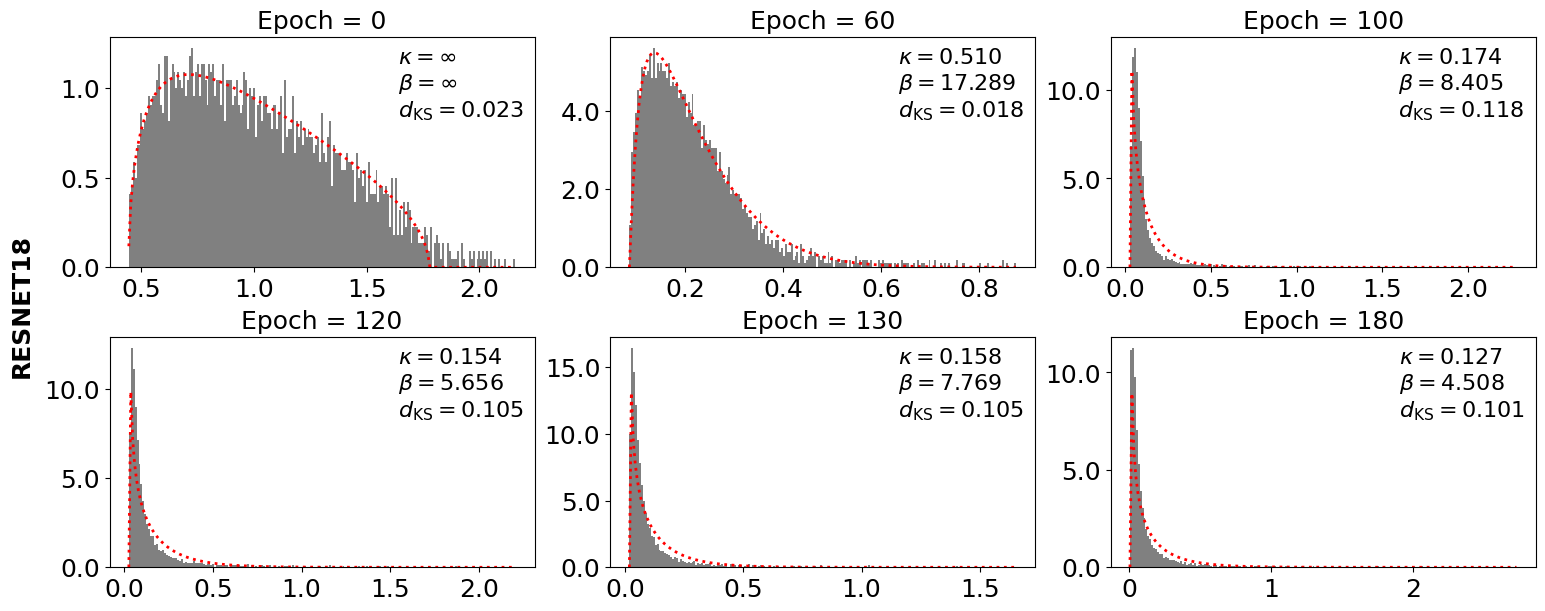

In [21]:
# Plot ESD fits
fit.plot_esd(epochs_list=[0, 60, 100, 120, 130, 180], 
             num_plots_per_row=3,
             log_bins=False, 
             n_bins=200, 
             log_y=False, 
             title=True, 
             fontsize=18, 
             plot_power=False, 
             plot_htmp=True, 
             fig_width=15,
             fig_height_per_row=3)

### Fit by-hand

1it [00:01,  1.97s/it]


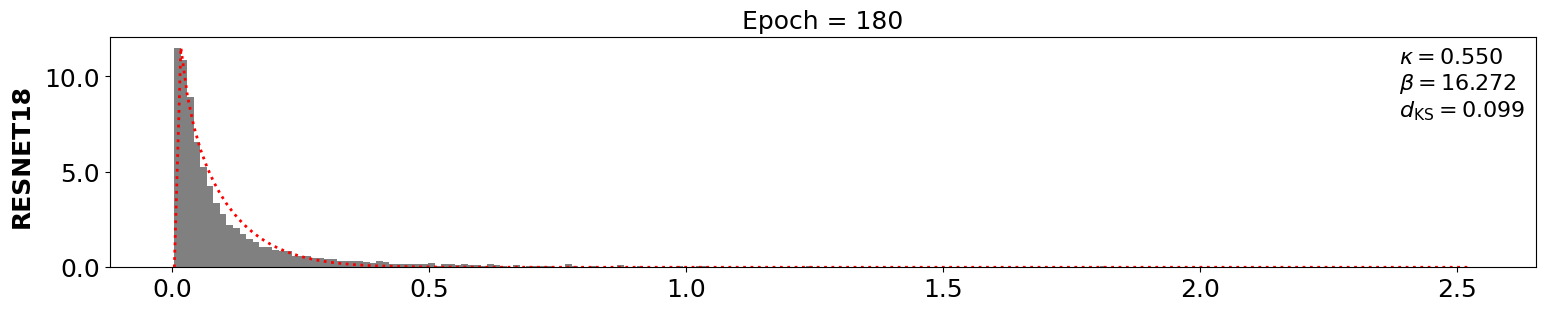

'results/htmp/fits\\resnet18_svhn_weight_b100_nonzero_layerlayer4.0.conv1_fit.pt'

In [ ]:
epoch = 180
c = 0.07
kappa = 0.55

fit.kappa_opt[epoch] = kappa
fit.beta_opt[epoch] = c / fit.tau_opt[epoch]
fit.plot_esd(epochs_list=[epoch], log_bins=False, n_bins=200, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)
# fit.compute_ks_distance_epoch(epoch)
# fit.print_htmp_fit_summary(epoch)

fit.save_htmp_fit()

1it [00:02,  2.16s/it]


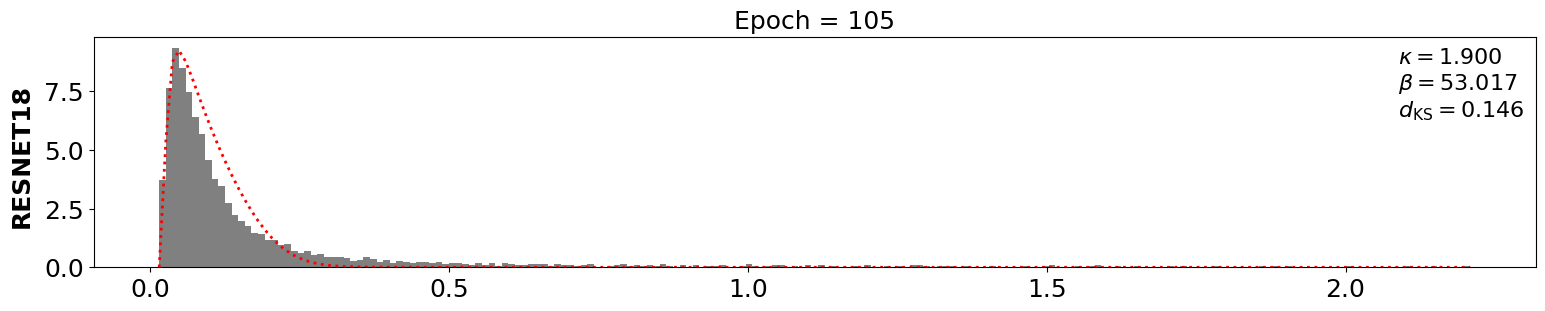

In [ ]:
epoch = 105
c = 0.8
kappa = 1.9

fit.kappa_opt[epoch] = kappa
fit.beta_opt[epoch] = c / fit.tau_opt[epoch]
fit.plot_esd(epochs_list=[epoch], log_bins=False, n_bins=200, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)
# fit.compute_ks_distance_epoch(epoch)
# fit.print_htmp_fit_summary(epoch)

1it [00:01,  1.96s/it]


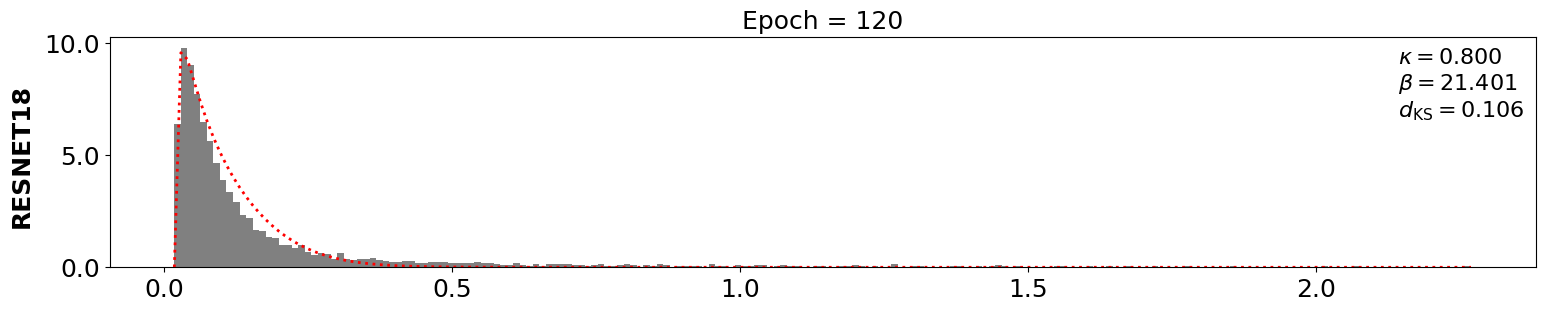

In [ ]:
epoch = 120
c = 0.45
kappa = 0.8

fit.kappa_opt[epoch] = kappa
fit.beta_opt[epoch] = c / fit.tau_opt[epoch]
fit.plot_esd(epochs_list=[epoch], log_bins=False, n_bins=200, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)
# fit.compute_ks_distance_epoch(epoch)
# fit.print_htmp_fit_summary(epoch)

### Training vs. Epoch

First epoch reaching train acc 0.995: 10


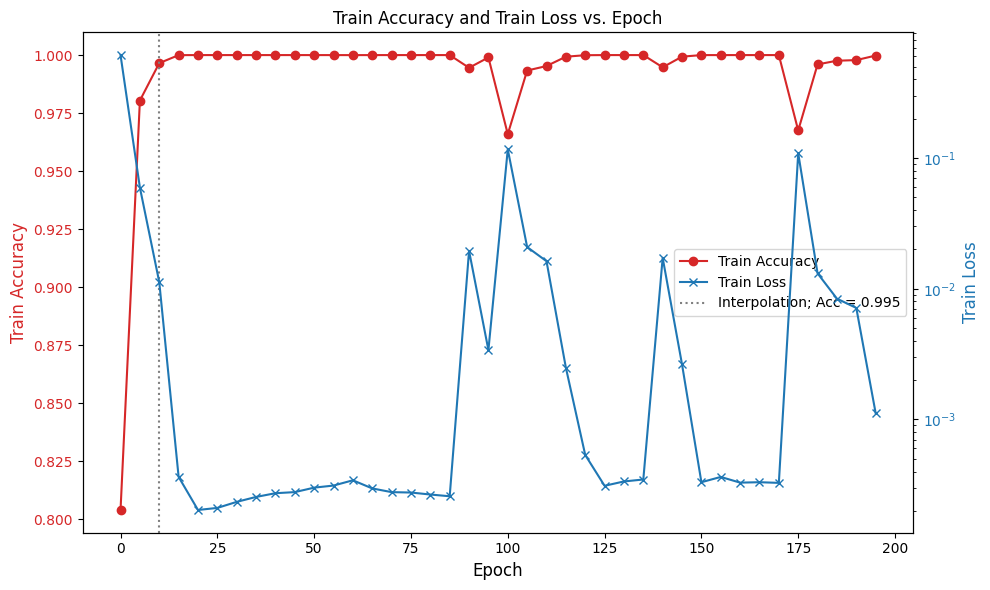

In [22]:
fit.plot_train_acc_and_train_loss(interp_acc=0.995, log_scale_loss=True, show_fig=True, save_fig=False)

### Free Energy vs Test

Max test accuracy at epoch 165, lambda = 17.46866105332327
---- Corr ----
SpearmanCorr: 0.756
Kendall Tau: 0.582, p-value: 1.2260446123813972e-07
Pearson r: 0.887


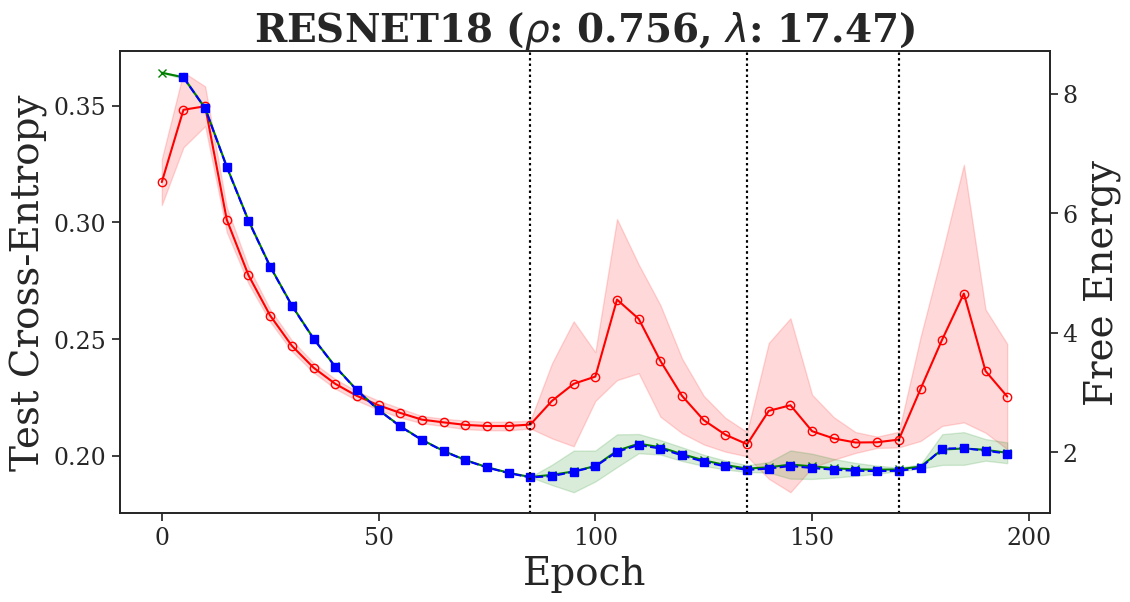

Correlation between Test Cross-Entropy and Free Energy: 0.756
Maximum Test Cross-Entropy: 0.350 at Epoch=10, Free Energy=7.75838


In [28]:
# lambas = {
#     'resnet18': 3,
#     'resnet34': 6,
#     'resnet50': 6,
# }
# lam = lambas[fit.model]

start_index = 0
x_var = 'epochs'

max_acc_epoch_index = np.argmax([fit.fileloader.get_test_acc_epoch(epoch) for epoch in range(5*start_index, 200, 5)])
max_acc_epoch = 5*start_index + 5 * max_acc_epoch_index
lam = 1 / fit.fileloader.get_eigs_epoch(max_acc_epoch).mean()
print(f"Max test accuracy at epoch {max_acc_epoch}, lambda = {lam}")

if x_var == 'kappa_beta_ratio':
    # Compute optimal kappa/beta ratio
    kappa = np.array([fit.kappa_opt[epoch] for epoch in fit.epoch_list[start_index:]]).mean()
    c = np.array([fit.beta_opt[epoch] * fit.tau_opt[epoch] for epoch in fit.epoch_list[start_index:]]).mean()
    gamma = fit._get_gamma()

    opt_ratio = 2*gamma*kappa / (lam *(kappa + 2*gamma*c))
    print(fr'Optimal kappa/beta ratio: {opt_ratio}, $\lambda$ = {lam}')
else:
    opt_ratio = None

# Plot free energy fits
fit.compute_free_energy(lam=lam, tau=0, weight_inverse=True)

fit.plot_test_vs_free(variable=x_var, 
                      acc_key='test_loss',
                      neg_free=False, 
                      start_index =start_index, 
                      plot_theoretical_free=True, 
                      single_plot=True, 
                      fig_height=6, 
                      fig_width=12,
                      fontsize=28, 
                      ticksize=17,
                      texplot_enabled=True,
                      optimal_ratio=opt_ratio,
                      marker_size=450,
                      tight_layout=False,
                      legend_on=False,
                      legendbox=False,
                      vline_epochs=[85, 135, 170],
                      vline_width=1.5,
                      legendsize=24)

### Ratio vs. Epochs

Skipping epochs for κ/β plot: 5 (missing kappa/beta), 10 (missing kappa/beta), 15 (missing kappa/beta), 20 (missing kappa/beta), 25 (missing kappa/beta), 30 (missing kappa/beta), 35 (missing kappa/beta)


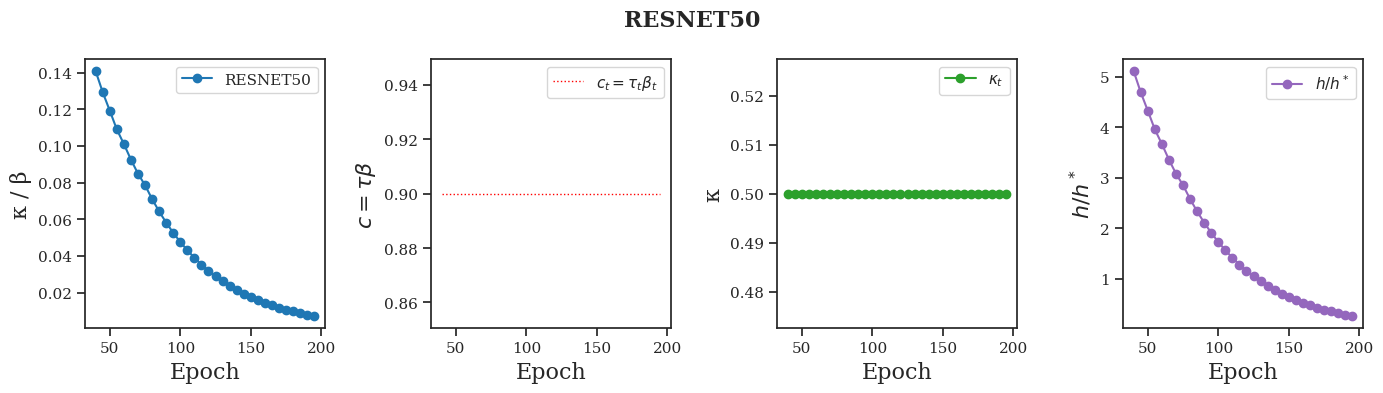

array([<Axes: xlabel='Epoch', ylabel='κ / β'>,
       <Axes: xlabel='Epoch', ylabel='$c=\\tau\\beta$'>,
       <Axes: xlabel='Epoch', ylabel='κ'>,
       <Axes: xlabel='Epoch', ylabel='$h/h^*$'>], dtype=object)

In [26]:
fit.plot_kappa_beta_ratio_vs_epoch(
    start_index=1,
    plot_c=True,
    c_color='red',
    c_label=r'$c_t=\tau_t\beta_t$',
    title=True,
    fig_width=14,
    fig_height=4,
    fontsize=16,
    texplot_enabled=True,
    show_fig=True,
    c_lw=1,
    separate_plots = True,
    alignment='horizontal', 
    # vline_epochs=[85, 135, 170],
    lam = lam,
    plot_h_over_h_star=True,
)

### Trace and Log Det vs Var

Log-Det at epoch 1: empirical=-1.68
Min free energy epoch: 135, min empirical free energy: 1.28


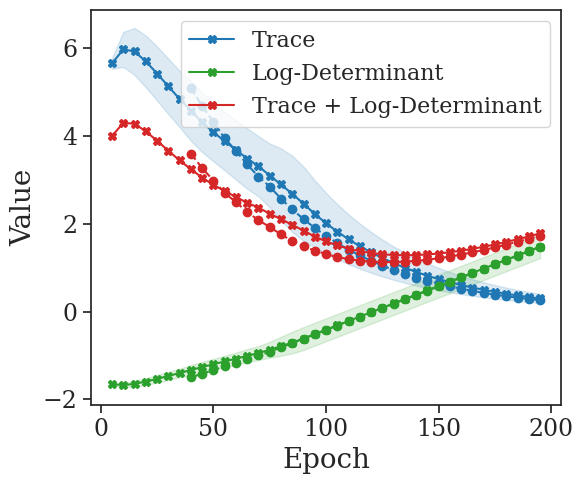

In [27]:
trace_variable = 'epochs'  # 'epochs', 'kappa', 'beta', or 'kappa_beta_ratio'
start_index = 1
fit.compute_free_energy(lam=lam, tau=0, weight_inverse=True)
fit.plot_trace_and_log_det(variable=trace_variable, 
                           plot_theoretical=True, 
                           start_index=start_index, 
                           plot_sum=True, 
                           fig_height=5, 
                           fig_width=6, 
                           fontsize=20, 
                           ticksize=17,
                           legendsize=16,
                           texplot_enabled=True,
                           legend_on=True,
                           title=False,
                           single_axis=True,
                           x_log_scale=False)

### Plot kappa/beta vs epochs for all resnets

Plotting κ/β ratio vs. epoch on provided axes.
c = 1.4000000000000001
Plotting κ/β ratio vs. epoch on provided axes.
c = 1.0
Plotting κ/β ratio vs. epoch on provided axes.
c = 0.9


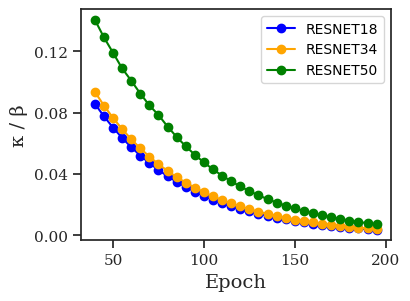

In [28]:
import esdfit as esdfit
import numpy as np
from importlib import reload; reload(esdfit)
import matplotlib.pyplot as plt
import texplot
texplot.set_theme()
models = ['resnet18', 'resnet34', 'resnet50']
colors = ['blue', 'orange', 'green']
fig, ax = plt.subplots(figsize=(4, 3))

for model, color in zip(models, colors):
    # Load fits
    fit = esdfit.ESDFit(model=model, dataset='cifar10', kernel='weight', batch_size=100, subsample=False, file_dir = 'results/htmp/epoch')
    fit.load_htmp_fit()
    ax = fit.plot_kappa_beta_ratio_vs_epoch(
        start_index=8,
        title=False,
        fontsize=14,
        texplot_enabled=True,
        show_fig=False,
        save_fig=False,
        axes=ax,
        color_plot=color
    )
    print(f'c = {fit.beta_opt[fit.epoch_list[8]] * fit.tau_opt[fit.epoch_list[8]]}')
# ax.set_title(r'$\kappa/\beta$ Ratio vs. Epoch', fontsize=16, fontweight='bold')

# Have fewer number of ticks on both axes
ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))

ax.legend()
# fig.tight_layout()
fig.savefig('figures/paper/resnet_kappa_beta_ratio.pdf', bbox_inches='tight', format='pdf')
plt.show()    

# ModelZoo

In [10]:
import os
# Create a function that finds all the folders in a directory that begin with 'checkpoint_' and returns a list of the folder names
def find_checkpoints(directory):
    checkpoints = []
    for folder in os.listdir(directory):
        if folder.startswith('checkpoint_') and os.path.isdir(os.path.join(directory, folder)):
            checkpoints.append(int(folder.split('_')[-1]))
    return checkpoints

In [12]:
import torch
import pandas as pd
model_dataset = 'resnet18_cifar100'
dict_eigenvalues = {}
results = {}

seeds = [0,1,2,3,4,5,6,7,8,9]
checkpoints = find_checkpoints(f'data/modelzoo/{model_dataset}/seed_{seeds[0]}/')
for checkpoint in checkpoints:
    dict_eigenvalues[checkpoint] = []
    train_loss_checkpoint = []
    test_acc_checkpoint = []
    for seed in seeds:
        sd = torch.load(f'data/modelzoo/{model_dataset}/seed_{seed}/checkpoint_{checkpoint:06d}/checkpoints', weights_only=False, map_location=torch.device('cpu'))
        W = sd['fc.weight'].cpu().detach()
        # W = sd['layer4.0.conv2.weight'].flatten(1).cpu().detach()
        eigenvalues = torch.linalg.eigvalsh(W @ W.t())
        dict_eigenvalues[checkpoint].append(eigenvalues)

        df = pd.read_csv(f'data/modelzoo/{model_dataset}/seed_{seed}/progress.csv')
        row = df.iloc[checkpoint]
        train_loss_checkpoint.append(row.train_loss.item())
        test_acc_checkpoint.append(row.test_acc.item())

    eigenvalues = torch.cat(dict_eigenvalues[checkpoint])
    print(f'Checkpoint = {checkpoint}, $\tau$ = {eigenvalues.min():.3f}, 10: {sorted(eigenvalues)[9]:.3f}, 11: {sorted(eigenvalues)[10]:.3f}')
    print(f'')
    dict_eigenvalues[checkpoint] = eigenvalues
    logdet = torch.sum(torch.log(eigenvalues + 1e-6)).item() / len(eigenvalues)
    trace = torch.sum(eigenvalues).item() / len(eigenvalues)

    results[checkpoint] = {
        'logdet': logdet,
        'trace': trace,
        'training_loss': sum(train_loss_checkpoint) / len(train_loss_checkpoint),
        'test_acc': sum(test_acc_checkpoint) / len(test_acc_checkpoint),
    }

Checkpoint = 0, $	au$ = 0.618, 10: 0.693, 11: 0.694

Checkpoint = 1, $	au$ = 0.605, 10: 0.675, 11: 0.677

Checkpoint = 2, $	au$ = 0.590, 10: 0.650, 11: 0.653

Checkpoint = 5, $	au$ = 0.504, 10: 0.560, 11: 0.563

Checkpoint = 10, $	au$ = 0.369, 10: 0.425, 11: 0.425

Checkpoint = 20, $	au$ = 0.075, 10: 0.092, 11: 0.319

Checkpoint = 30, $	au$ = 0.010, 10: 0.012, 11: 0.268

Checkpoint = 35, $	au$ = 0.004, 10: 0.005, 11: 0.259

Checkpoint = 40, $	au$ = 0.002, 10: 0.002, 11: 0.251

Checkpoint = 45, $	au$ = 0.001, 10: 0.001, 11: 0.230

Checkpoint = 50, $	au$ = 0.001, 10: 0.001, 11: 0.218

Checkpoint = 55, $	au$ = 0.000, 10: 0.001, 11: 0.200

Checkpoint = 60, $	au$ = 0.000, 10: 0.001, 11: 0.196



## ESDFit

In [ ]:
# Convert raw ModelZoo checkpoints into ESDFit-compatible summary files
from helpers import save_all_modelzoo_checkpoint_summaries

model = "resnet18"
dataset = "cifar100"

paths = save_all_modelzoo_checkpoint_summaries(
    model_name=model,
    dataset=dataset,
    # Optional:
    # steps=[0, 1, 2, 5, 10],
    # seeds=[0, 1, 2],
    data_root="data/modelzoo",
    results_dir="results/htmp/epoch",
    verbose=True,
)

print(f"Saved {len(paths)} summary files")
print(paths[:5])

Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_0_43.pt
Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_1_43.pt
Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_2_43.pt
Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_5_43.pt
Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_10_43.pt
Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_20_43.pt
Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_30_43.pt
Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_40_43.pt
Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_50_43.pt
Saved ModelZoo summary: results\htmp\epoch\aggregated_bottom_10\resnet18_cifar100_b128_60_43.pt
Saved 10 summary files
[WindowsPath('results

In [29]:
# Load ModelZoo classifier-head weights with ESDFit
import esdfit
from importlib import reload
reload(esdfit)

model = "resnet18"
dataset = "cifar100"
batch_size = 128  # from data/modelzoo/.../params.json

fit = esdfit.ESDFit(
    model=model,
    dataset=dataset,
    kernel="weight",
    batch_size=batch_size,
    subsample=False,
    file_dir="results/htmp/epoch",
    weight_type="FC",
    trim_bottom_eigs=11,
)
fit.load_htmp_fit()

True

### Fit HTMP

In [129]:
fit.fit_htmp(search_method='grid', 
             shared_beta_grid=False, 
             beta_from_tau=True,
             c = 0.075,
             kappa_min=0.1, 
             kappa_max=1, 
             num_kappas=100, 
             kappa_log_scale=False,
             n_eval=100, 
             beta_min=0.1, 
             beta_max = 1, 
             num_betas = 10, 
             tau_min=0,
             tau_max=0,
             num_taus=1,
             epochs_list=[20] + list(range(30, 65, 5)),
             moment_penalty_weight=0.1,
             verbose=True,
             extra_verbose=True,
             shared_tau_grid=False,
             stieltjes=False,
             vectorized_grid=True,
             save_fit=True)

Loading eigenvalues...
Fitting HTMP parameters for 8 epochs using grid search...
Beta grid arguments are ignored: beta is set per epoch to 0.075 / tau.
Best grid point: kappa=0.3636, beta=0.2353, distance=0.180292
Fitting HTMP for Epoch: 20, κ*: 0.364, β*: 0.235, τ*: 0.319, ||.||ₚ*: 0.180
Best grid point: kappa=0.4273, beta=0.2796, distance=0.230882
Fitting HTMP for Epoch: 30, κ*: 0.427, β*: 0.280, τ*: 0.268, ||.||ₚ*: 0.231
Best grid point: kappa=0.4545, beta=0.2797, distance=0.222939
Fitting HTMP for Epoch: 35, κ*: 0.455, β*: 0.280, τ*: 0.268, ||.||ₚ*: 0.223
Best grid point: kappa=0.4545, beta=0.3088, distance=0.250138
Fitting HTMP for Epoch: 40, κ*: 0.455, β*: 0.309, τ*: 0.243, ||.||ₚ*: 0.250
Best grid point: kappa=0.4818, beta=0.3228, distance=0.260965
Fitting HTMP for Epoch: 45, κ*: 0.482, β*: 0.323, τ*: 0.232, ||.||ₚ*: 0.261
Best grid point: kappa=0.4818, beta=0.3467, distance=0.283752
Fitting HTMP for Epoch: 50, κ*: 0.482, β*: 0.347, τ*: 0.216, ||.||ₚ*: 0.284
Best grid point: kap

### Plot ESD

0it [00:00, ?it/s]

5it [00:00,  7.74it/s]


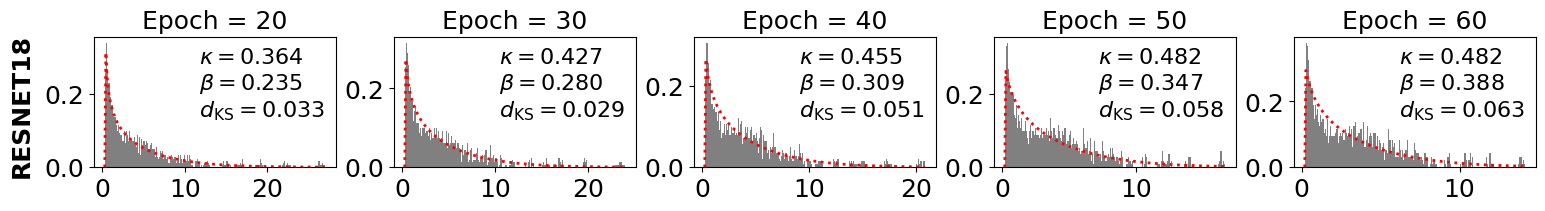

In [30]:
# Plot ESD fits
fit.plot_esd(epochs_list=[20, 30, 40, 50, 60], 
             log_bins=False, 
             n_bins=200, 
             log_y=False, 
             title=True, 
             fontsize=18, 
             plot_power=False, 
             plot_htmp=True, 
             fig_width=15,
             fig_height_per_row=2)

### Fit by-hand

1it [00:00,  8.70it/s]


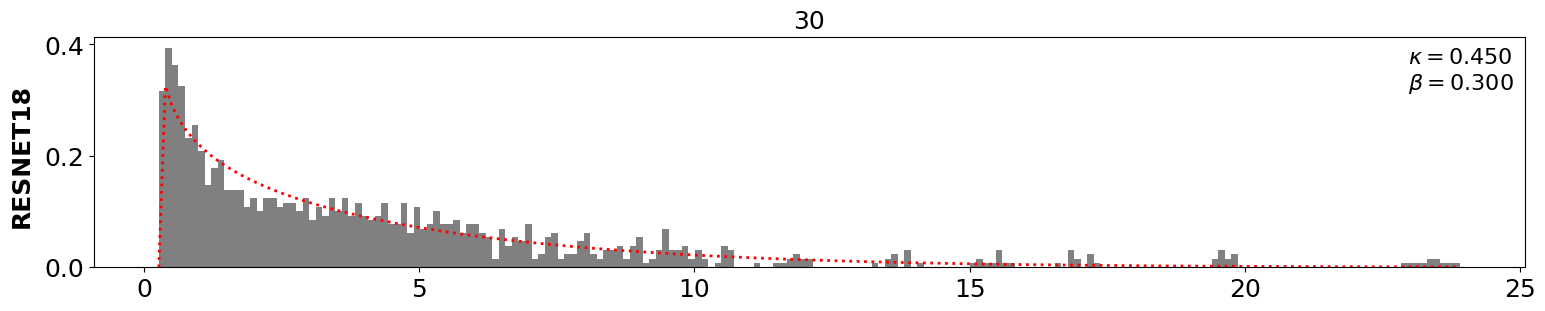

In [124]:
fit.kappa_opt[30] = 0.45
fit.beta_opt[30] = 0.300
fit.plot_esd(epochs_list=[30], log_bins=False, n_bins=200, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)

1it [00:00,  7.69it/s]


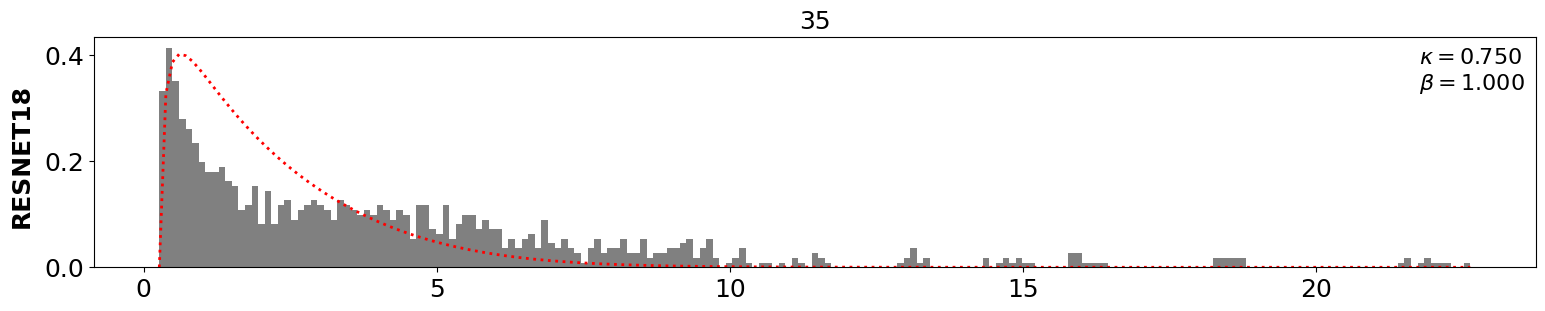

In [21]:
fit.kappa_opt[35] = 0.75
fit.beta_opt[35] = 1
fit.plot_esd(epochs_list=[35], log_bins=False, n_bins=200, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)

1it [00:00, 10.25it/s]


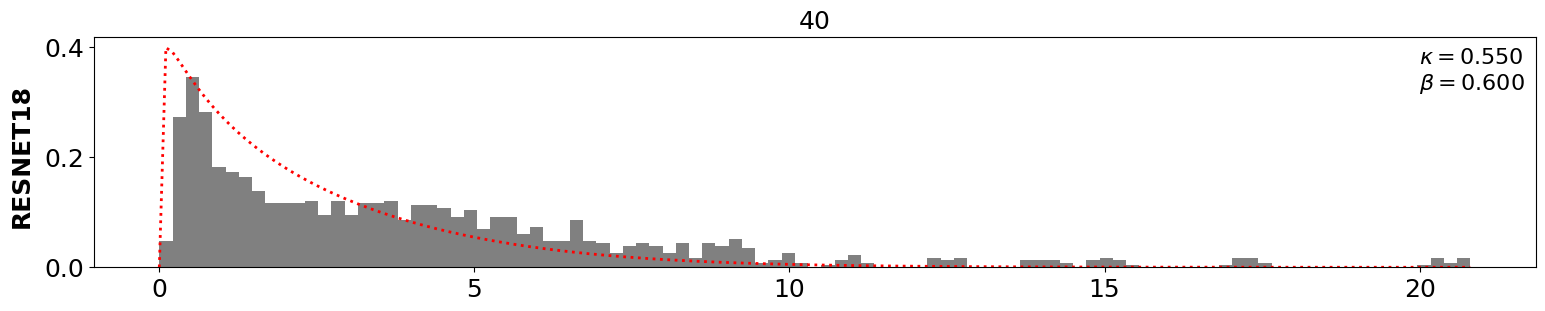

In [145]:
fit.kappa_opt[40] = 0.55
fit.beta_opt[40] = 0.6
fit.plot_esd(epochs_list=[40], log_bins=False, n_bins=100, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)

1it [00:00, 12.23it/s]


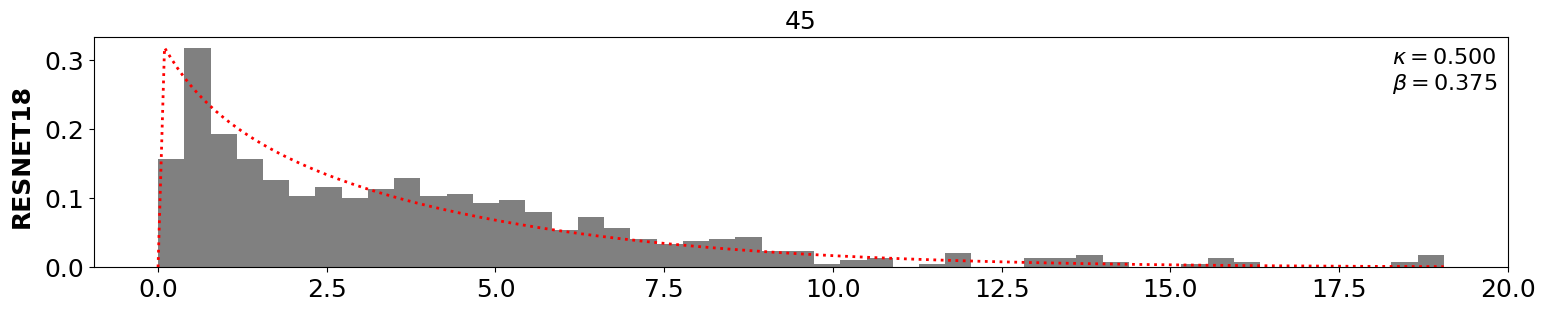

In [123]:
fit.kappa_opt[45] = 0.5
fit.beta_opt[45] = 0.375
fit.plot_esd(epochs_list=[45], log_bins=False, n_bins=50, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)

1it [00:00,  8.21it/s]


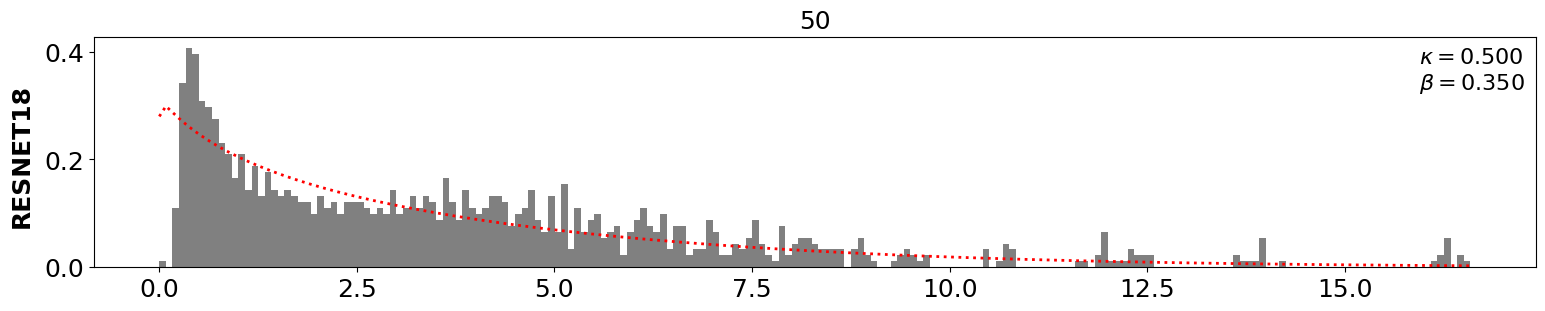

In [4]:
fit.kappa_opt[50] = 0.5
fit.beta_opt[50] = 0.35
fit.plot_esd(epochs_list=[50], log_bins=False, n_bins=200, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)

1it [00:00, 12.80it/s]


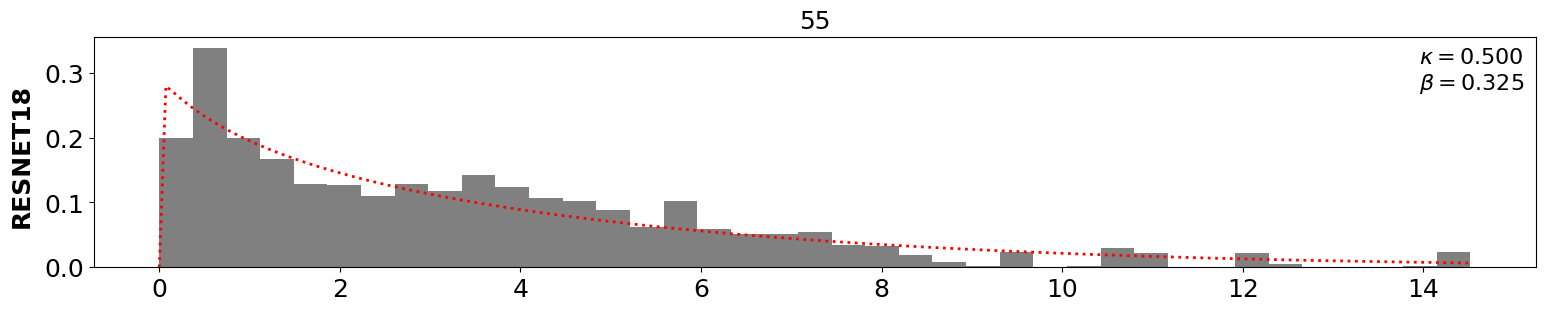

In [125]:
fit.kappa_opt[55] = 0.5
fit.beta_opt[55] = 0.325
fit.plot_esd(epochs_list=[55], log_bins=False, n_bins=40, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)

1it [00:00,  8.61it/s]


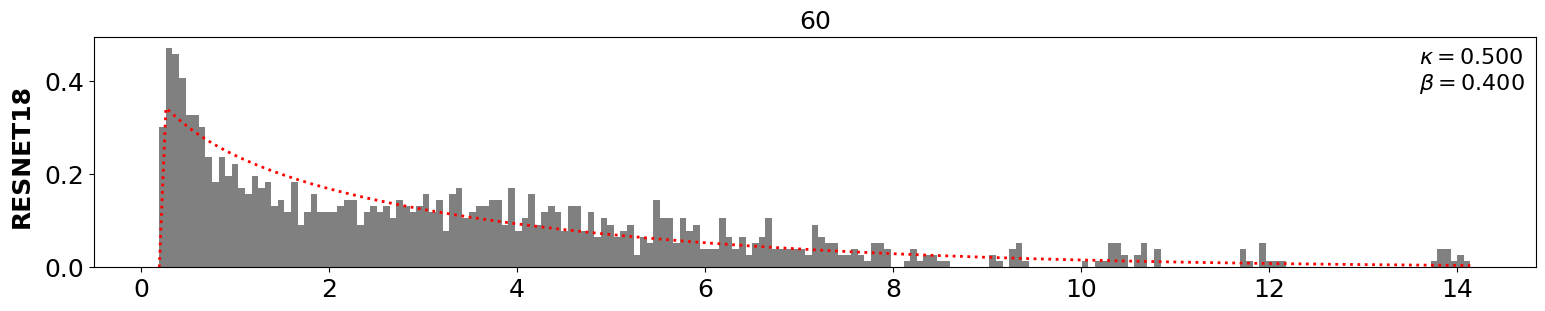

In [103]:
fit.kappa_opt[60] = 0.5
fit.beta_opt[60] = 0.4
fit.plot_esd(epochs_list=[60], log_bins=False, n_bins=200, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)

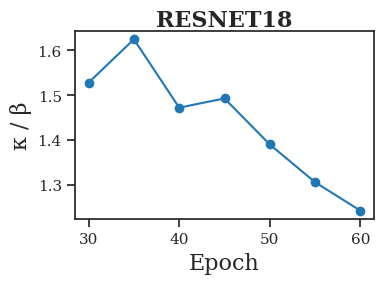

<Axes: title={'center': 'RESNET18'}, xlabel='Epoch', ylabel='κ / β'>

In [31]:
fit.plot_kappa_beta_ratio_vs_epoch(
    start_index=6,
    title=True,
    fig_width=4,
    fig_height=3,
    fontsize=16,
    texplot_enabled=True,
    show_fig=True,
)

### Free Energy vs. Test

Optimal kappa/beta ratio: 1.2343866185156624
---- Corr ----
SpearmanCorr: 0.964
Kendall Tau: 0.905, p-value: 0.002777777777777778
Pearson r: 0.976


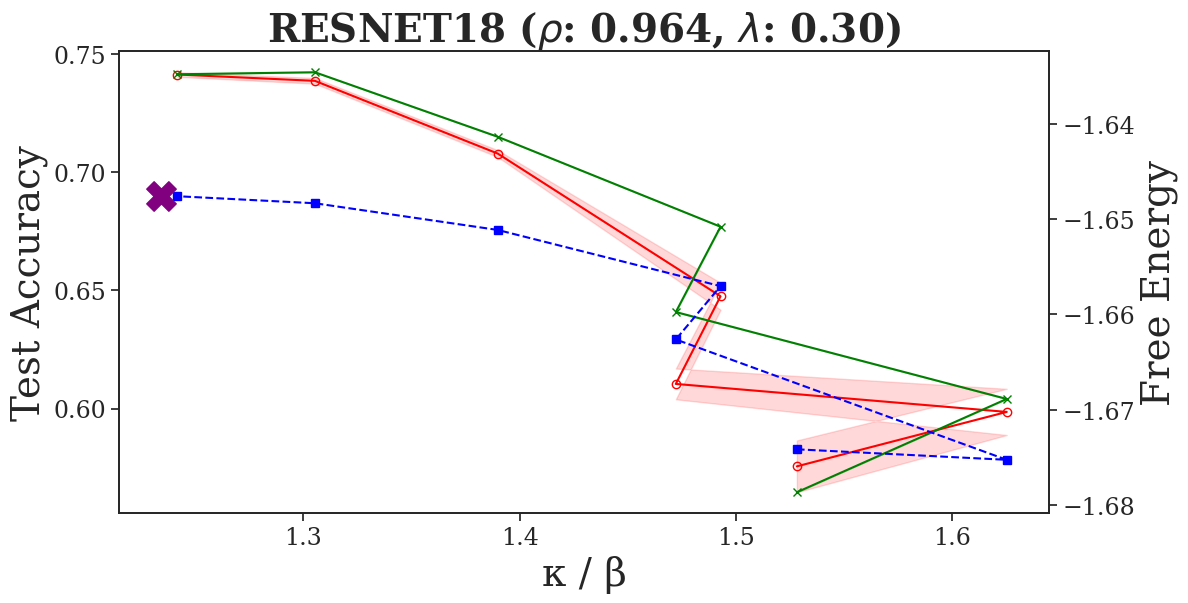

Correlation between Test Accuracy and -Free Energy: 0.964
Maximum Test Accuracy: 0.741 at κ / β=1.24, Free Energy=-1.63481


In [32]:
import numpy as np
start_index = 6
x_var = 'kappa_beta_ratio'  # 'epochs', 'kappa', 'beta', or 'kappa_beta_ratio'

max_acc_epoch_index = np.argmax([fit.fileloader.get_test_acc_epoch(epoch) for epoch in range(30, 65, 5)])
max_acc_epoch = 5*start_index + 5 * max_acc_epoch_index
lam = 1 / fit.fileloader.get_eigs_epoch(max_acc_epoch).mean()

if x_var == 'kappa_beta_ratio':
    # Compute optimal kappa/beta ratio
    kappa = np.array([fit.kappa_opt[epoch] for epoch in fit.epoch_list[start_index:]]).mean()
    c = np.array([fit.beta_opt[epoch] * fit.tau_opt[epoch] for epoch in fit.epoch_list[start_index:]]).mean()
    gamma = fit._get_gamma(60)

    opt_ratio = 2*gamma*kappa / (lam *(kappa + 2*gamma*c))
    print(f'Optimal kappa/beta ratio: {opt_ratio}')
else:
    opt_ratio = None


# Plot free energy fits
fit.compute_free_energy(lam=lam, tau=0, weight_inverse=True)

fit.plot_test_vs_free(variable=x_var, 
                      neg_free='True', 
                      start_index =start_index, 
                      plot_theoretical_free=True, 
                      single_plot=True, 
                      fig_height=6, 
                      fig_width=12,
                      fontsize=28, 
                      ticksize=17,
                      texplot_enabled=True,
                      optimal_ratio=opt_ratio,
                      marker_size=450,
                      tight_layout=False,
                      legend_on=False,
                      legendbox=False,
                      legendsize=24)

### Trace and Log Det vs Var

Log-Det at epoch 6: empirical=0.424
Min free energy epoch: 55, min empirical free energy: 1.43


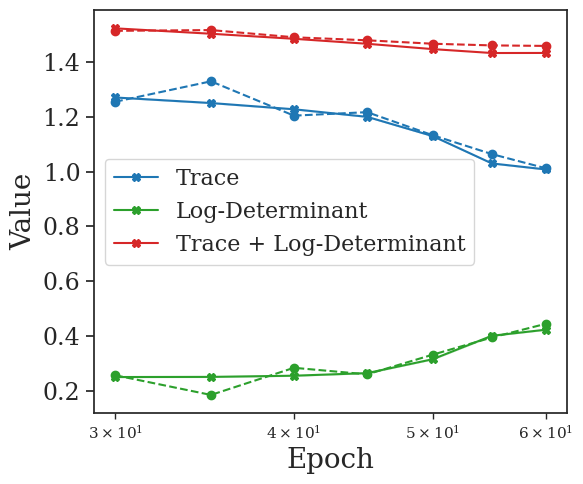

In [33]:
trace_variable = 'epochs'  # 'epochs', 'kappa', 'beta', or 'kappa_beta_ratio'
start_index = 6
fit.compute_free_energy(lam=0.3, tau=0, weight_inverse=True)
fit.plot_trace_and_log_det(variable=trace_variable, 
                           plot_theoretical=True, 
                           start_index=start_index, 
                           plot_sum=True, 
                           fig_height=5, 
                           fig_width=6, 
                           fontsize=20, 
                           ticksize=17,
                           legendsize=16,
                           texplot_enabled=True,
                           legend_on=True,
                           title=False,
                           single_axis=True,
                           x_log_scale=True)

# Permuted Labels Test

## Load HTMP

In [1]:
import esdfit as esdfit
import numpy as np
from importlib import reload; reload(esdfit)

fit = esdfit.ESDFit(
    model='resnet18',
    dataset='cifar10',
    kernel='weight',
    batch_size=100,
    file_dir='results/htmp/epoch',
    permuted_labels=True,
    layer='layer4.0.conv1',
    nonzero_eigs_only=True,
)
fit.load_htmp_fit()

# fit.print_available_layers()

True

In [7]:
fit._get_gamma()

0.1111111111111111

## Fit HTMP

In [12]:
fit.fit_htmp(search_method='grid', 
             method = 'ks',
             shared_beta_grid=False, 
             beta_from_tau=True,
             c = 0.35,
             kappa_min=0.2, 
             kappa_max=1, 
             num_kappas=10, 
             kappa_log_scale=False,
             n_eval=100, 
             beta_min=0.1, 
             beta_max = 5, 
             num_betas = 10, 
             tau_min=0,
             tau_max=0,
             num_taus=1,
             epochs_list=[range(0, 200, 5)],
             moment_penalty_weight=1,
             verbose=True,
             extra_verbose=True,
             shared_tau_grid=False,
             vectorized_grid=True,
             save_fit=True)

Loading eigenvalues...
Fitting HTMP parameters for 39 epochs using grid search...
Beta grid arguments are ignored: beta is set per epoch to 0.35 / tau.
HTMP fit method: ks
Fitting HTMP for Epoch: 0, κ*: inf, β*: inf, τ*: 0.2744654417037964, ||.||ₚ*: None
Best grid point: kappa=0.4667, beta=1.408, distance=0.135025
Fitting HTMP for Epoch: 5, κ*: 0.467, β*: 1.408, τ*: 0.248, ||.||ₚ*: 0.135
Best grid point: kappa=0.7333, beta=1.512, distance=0.088451
Fitting HTMP for Epoch: 10, κ*: 0.733, β*: 1.512, τ*: 0.231, ||.||ₚ*: 0.088
Best grid point: kappa=0.9111, beta=1.476, distance=0.0429997
Fitting HTMP for Epoch: 15, κ*: 0.911, β*: 1.476, τ*: 0.237, ||.||ₚ*: 0.043
Best grid point: kappa=0.9111, beta=1.072, distance=0.0295302
Fitting HTMP for Epoch: 20, κ*: 0.911, β*: 1.072, τ*: 0.326, ||.||ₚ*: 0.030
Best grid point: kappa=0.8222, beta=0.8156, distance=0.0239521
Fitting HTMP for Epoch: 25, κ*: 0.822, β*: 0.816, τ*: 0.429, ||.||ₚ*: 0.024
Best grid point: kappa=0.8222, beta=0.752, distance=0.026

## Fit by hand

1it [00:00,  9.58it/s]


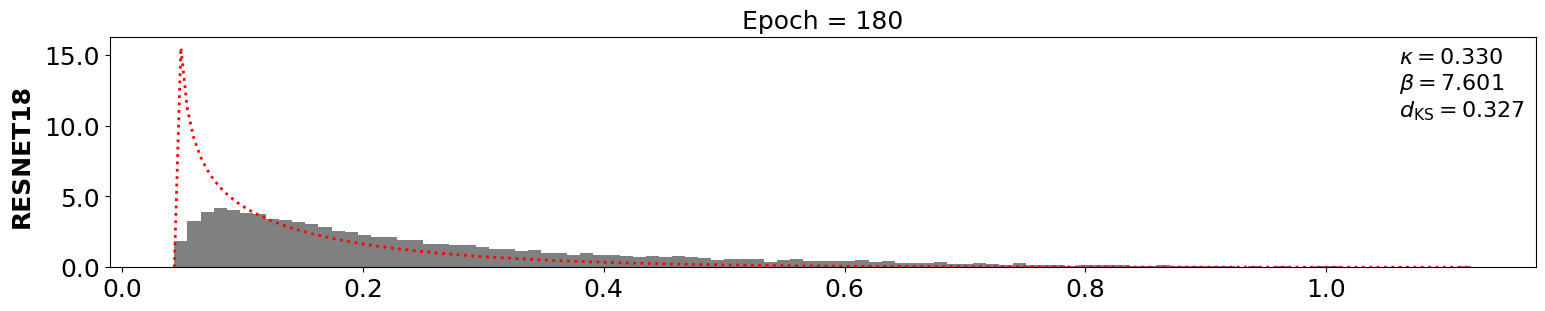

In [11]:
fit.kappa_opt[180] = 0.33
fit.beta_opt[180] = 0.33 / fit.tau_opt[180]
fit.plot_esd(epochs_list=[180], log_bins=False, n_bins=100, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)
# fit.compute_ks_distance_epoch(90)
# fit.print_htmp_fit_summary(90)

In [35]:
fit.kappa_opt[60] / fit.beta_opt[60]

0.5162386074662207

## Plot ESD

0it [00:00, ?it/s]

6it [00:00,  9.85it/s]


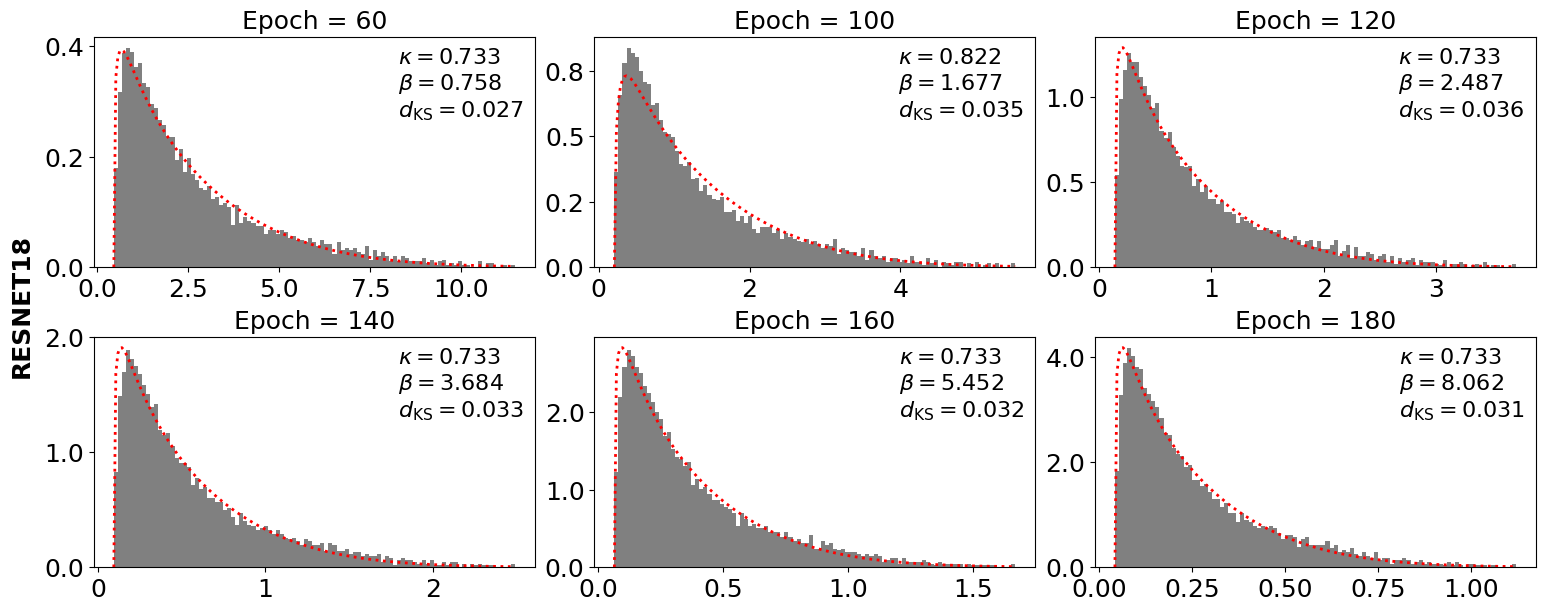

In [13]:
# Plot ESD fits
fit.plot_esd(epochs_list=[60, 100, 120, 140, 160, 180], 
             num_plots_per_row=3,
             log_bins=False, 
             n_bins=100, 
             log_y=False, 
             title=True, 
             fontsize=18, 
             plot_power=False, 
             plot_htmp=True, 
             fig_width=15,
             fig_height_per_row=3)

## Training vs. Epochs

First epoch reaching train acc 0.99: 55


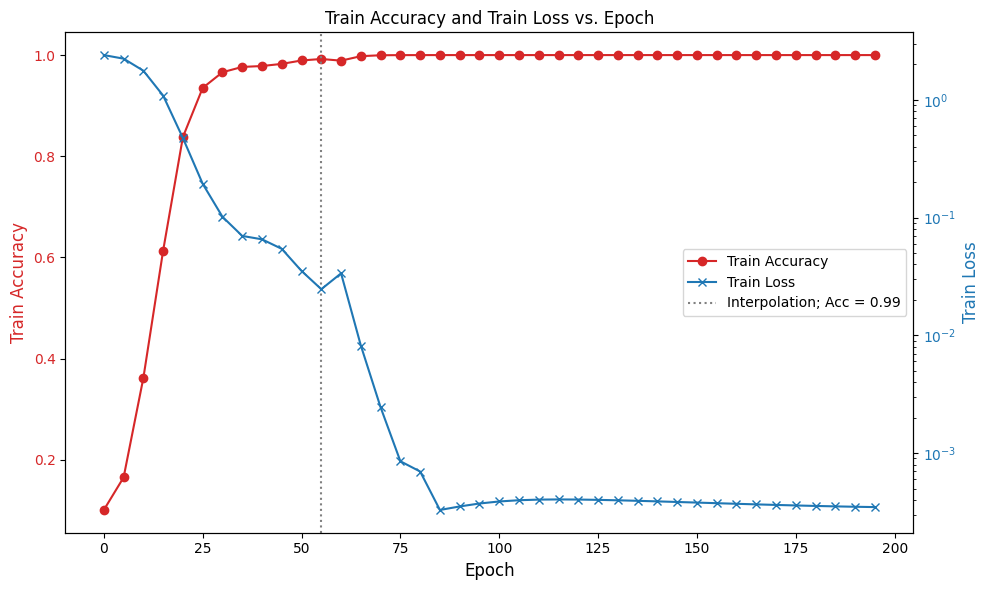

In [14]:
fit.plot_train_acc_and_train_loss(interp_acc=0.99, log_scale_loss=True, show_fig=True, save_fig=False)

## Free Energy vs. Test

Optimal kappa/beta ratio (unpermuted data): 0.0355
---- Corr ----
SpearmanCorr: 0.984
Kendall Tau: 0.927, p-value: 7.128138326486006e-23
Pearson r: 0.986


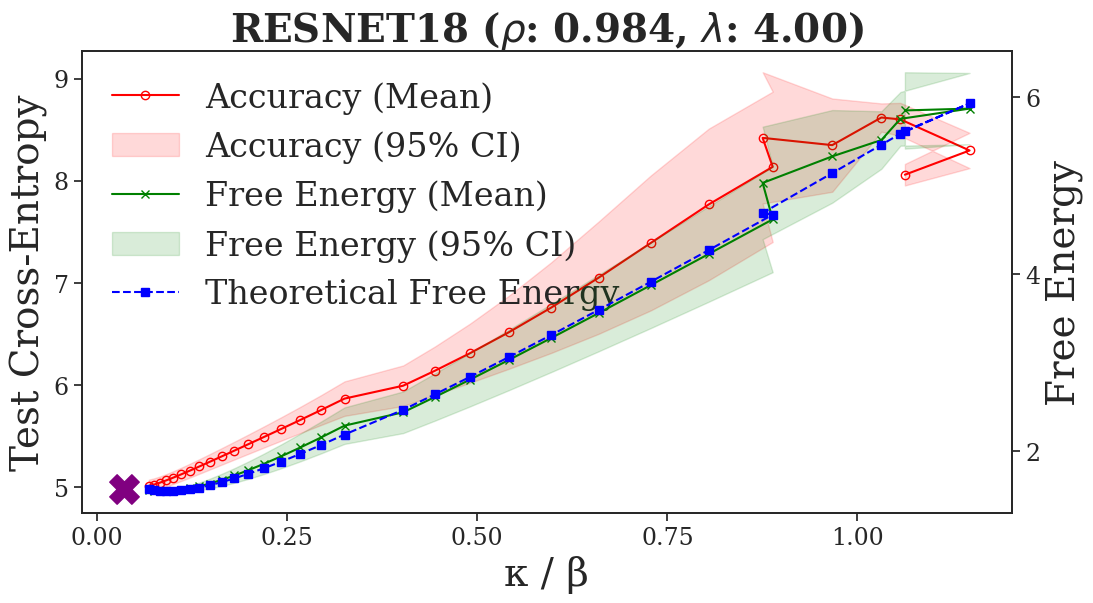

Correlation between Test Cross-Entropy and Free Energy: 0.984
Maximum Test Cross-Entropy: 8.618 at κ / β=1.03, Free Energy=5.51868


In [17]:
lambas = {
    'resnet18': 3.8642,
    'resnet34': 5.1597,
    'resnet50': 5.75837,
}
opt_h = {
    'resnet18': 0.0355,
    'resnet34': 0.0277,
    'resnet50': 0.0276,
}
lam = lambas[fit.model]

start_index = 8
max_epoch = 200
x_var = 'kappa_beta_ratio'

# max_acc_epoch_index = np.argmax([fit.fileloader.get_test_acc_epoch(epoch) for epoch in range(5*start_index, max_epoch, 5)])
# max_acc_epoch = 5*start_index + 5 * max_acc_epoch_index
# lam = 1 / fit.fileloader.get_eigs_epoch(max_acc_epoch).mean()

# lam = 3.8642356199853314 # ResNet18, same layer, trained on normal data, maximizes test acc

if x_var == 'kappa_beta_ratio':
    # Compute optimal kappa/beta ratio
    # kappa = np.array([fit.kappa_opt[epoch] for epoch in fit.epoch_list[start_index::]]).mean()
    # c = np.array([fit.beta_opt[epoch] * fit.tau_opt[epoch] for epoch in fit.epoch_list[start_index::]]).mean()
    # gamma = fit._get_gamma()

    # opt_ratio = 2*gamma*kappa / (lam *(kappa + 2*gamma*c))
    opt_ratio = opt_h[fit.model]
    print(f'Optimal kappa/beta ratio (unpermuted data): {opt_ratio}')
else:
    opt_ratio = None

lam = 4

# Plot free energy fits
fit.compute_free_energy(lam=lam, tau=0, weight_inverse=True)

fit.plot_test_vs_free(variable=x_var, 
                      acc_key='test_loss',
                      neg_free=False, 
                      start_index =start_index, 
                      plot_theoretical_free=True, 
                      single_plot=True, 
                      fig_height=6, 
                      fig_width=12,
                      fontsize=28, 
                      ticksize=17,
                      texplot_enabled=True,
                      optimal_ratio=opt_ratio,
                      marker_size=450,
                      tight_layout=False,
                      legend_on=True,
                      legendbox=False,
                      legendsize=24)

Plotting κ/β ratio vs. epoch on provided axes.
c = 0.35


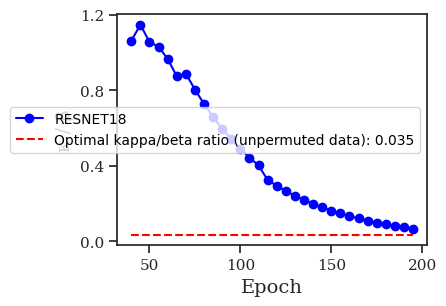

In [18]:
import esdfit as esdfit
import numpy as np
from importlib import reload; reload(esdfit)
import matplotlib.pyplot as plt
import texplot
texplot.set_theme()
models = ['resnet18']
colors = ['blue']
fig, ax = plt.subplots(figsize=(4, 3))

for model, color in zip(models, colors):
    # Load fits
    # fit = esdfit.ESDFit(model=model, dataset='cifar10', kernel='weight', batch_size=100, subsample=False, file_dir = 'data/htmp/epoch')
    # fit.load_htmp_fit()
    fit = esdfit.ESDFit(
        model=model,
        dataset='cifar10',
        kernel='weight',
        batch_size=100,
        file_dir='results/htmp/epoch',
        permuted_labels=True,
        layer='layer4.0.conv1',
        nonzero_eigs_only=True,
    )
    fit.load_htmp_fit()

    ax = fit.plot_kappa_beta_ratio_vs_epoch(
        start_index=8,
        title=False,
        fontsize=14,
        texplot_enabled=True,
        show_fig=False,
        save_fig=False,
        axes=ax,
        color_plot=color
    )
    print(f'c = {fit.beta_opt[fit.epoch_list[8]] * fit.tau_opt[fit.epoch_list[8]]}')
# ax.set_title(r'$\kappa/\beta$ Ratio vs. Epoch', fontsize=16, fontweight='bold')

ax.hlines(y=opt_h[fit.model], xmin=fit.epoch_list[8], xmax=fit.epoch_list[-1], colors='red', linestyles='dashed', label=f'Optimal kappa/beta ratio (unpermuted data): {opt_h[fit.model]:.3f}')
# Have fewer number of ticks on both axes
ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))

ax.legend()
# fig.tight_layout()
fig.savefig('figures/paper/resnet_kappa_beta_ratio.pdf', bbox_inches='tight', format='pdf')
plt.show()    

## Trace and Log-Det vs. Var

Log-Det at epoch 8: empirical=-2
Min free energy epoch: 195, min empirical free energy: 1.26


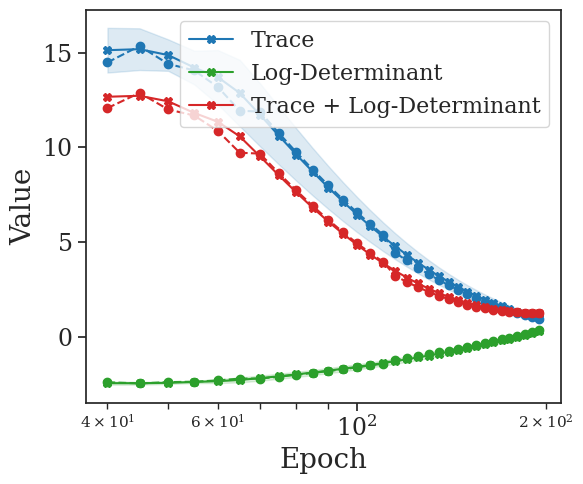

In [19]:
trace_variable = 'epochs'  # 'epochs', 'kappa', 'beta', or 'kappa_beta_ratio'
start_index = 8
fit.compute_free_energy(lam=5, tau=0, weight_inverse=True)
fit.plot_trace_and_log_det(variable=trace_variable, 
                           plot_theoretical=True, 
                           start_index=start_index, 
                           plot_sum=True, 
                           fig_height=5, 
                           fig_width=6, 
                           fontsize=20, 
                           ticksize=17,
                           legendsize=16,
                           texplot_enabled=True,
                           legend_on=True,
                           title=False,
                           single_axis=True,
                           x_log_scale=True)